# SmartTeaAI — SHAP Explainability

Explains predictions from the two best models:
- **LSTM** (winner, MAPE=3.22%) — `shap.DeepExplainer`
- **XGBoost (core)** (runner-up, MAPE=3.28%) — `shap.TreeExplainer` (exact TreeSHAP)

Charts saved to `data/charts/15_*` onwards.


In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import xgboost as xgb
import tensorflow as tf

warnings.filterwarnings('ignore')

DATA_DIR  = '../data'
MODEL_DIR = '../models'
CHART_DIR = '../data/charts'
TARGET    = 'price_national_avg'


C:\Users\Malmeee\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(f'{DATA_DIR}/train_set.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val_set.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test_set.csv')

for df in [train_df, val_df, test_df]:
    df['is_post_crisis'] = (pd.to_datetime(df['year_month']) >= '2022-04-01').astype(int)

y_test = test_df[TARGET].values
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} rows')


Train: 94 | Val: 20 | Test: 21 rows


## 1. LSTM — GradientExplainer

SHAP values are 3-dimensional . Summing across
the time-window gives a single contribution score per feature.

 is used instead of  because TF2 LSTM models
use internal ops () that DeepExplainer's gradient graph cannot trace.


In [3]:
lstm_model  = tf.keras.models.load_model(f'{MODEL_DIR}/lstm_model.keras')
lstm_scaler = joblib.load(f'{MODEL_DIR}/lstm_scaler.joblib')
with open(f'{MODEL_DIR}/lstm_meta.json') as f:
    lstm_meta = json.load(f)

W             = lstm_meta['window']
LSTM_FEATURES = [c for c in lstm_meta['features'] if c in train_df.columns]

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
X_all  = lstm_scaler.transform(all_df[LSTM_FEATURES].values)
n_tr, n_va = len(train_df), len(val_df)

X_seq       = np.array([X_all[i:i+W] for i in range(len(X_all)-W)])
X_seq_train = X_seq[:n_tr-W]
X_seq_test  = X_seq[n_tr+n_va-W:]

print(f'LSTM features : {len(LSTM_FEATURES)}')
print(f'Train seqs    : {X_seq_train.shape}')
print(f'Test  seqs    : {X_seq_test.shape}')


LSTM features : 16
Train seqs    : (91, 3, 16)
Test  seqs    : (21, 3, 16)


In [7]:
background     = X_seq_train[:80]
explainer_lstm = shap.GradientExplainer(lstm_model, background)

print('Computing LSTM SHAP values (GradientExplainer)...')
shap_raw = explainer_lstm.shap_values(X_seq_test)

shap_3d = np.array(shap_raw[0]) if isinstance(shap_raw, list) else np.array(shap_raw)
print(f'Raw shape from GradientExplainer: {shap_3d.shape}')

# GradientExplainer single-output regression may return (n, W, features, 1)
if shap_3d.ndim == 4:
    shap_3d = shap_3d[..., 0]  # drop trailing output dim -> (n, W, features)

shap_lstm      = shap_3d.sum(axis=1)      # sum over timesteps -> (n_test, n_features)
X_lstm_display = X_seq_test.mean(axis=1)  # avg feature values over window

print(f'shap_lstm shape: {shap_lstm.shape}  (expected: ({len(X_seq_test)}, {len(LSTM_FEATURES)}))')


Computing LSTM SHAP values (GradientExplainer)...
Raw shape from GradientExplainer: (21, 3, 16, 1)
shap_lstm shape: (21, 16)  (expected: (21, 16))


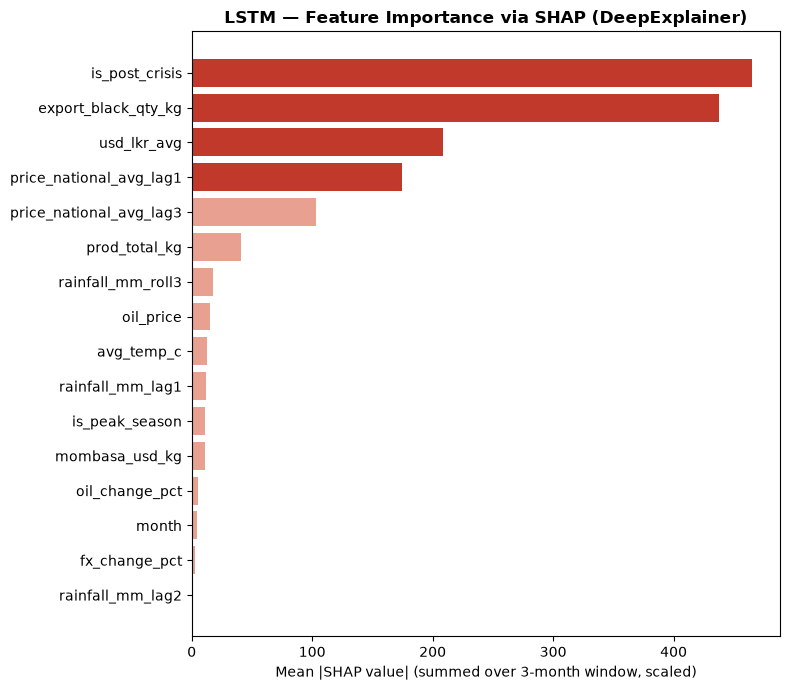

Saved: 15_lstm_shap_bar.png

Top 5 LSTM features:
                feature  importance
price_national_avg_lag3  103.245078
price_national_avg_lag1  174.508928
            usd_lkr_avg  208.647479
    export_black_qty_kg  437.332430
         is_post_crisis  465.073498


In [8]:
mean_abs = np.abs(shap_lstm).mean(axis=0)
imp_df   = pd.DataFrame({'feature': LSTM_FEATURES, 'importance': mean_abs})\
             .sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
threshold = imp_df['importance'].quantile(0.75)
colors = ['#C0392B' if v >= threshold else '#E8A090' for v in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.set_xlabel('Mean |SHAP value| (summed over 3-month window, scaled)')
ax.set_title('LSTM — Feature Importance via SHAP (DeepExplainer)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/15_lstm_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_lstm_shap_bar.png')
print('\nTop 5 LSTM features:')
print(imp_df.tail(5)[['feature','importance']].to_string(index=False))


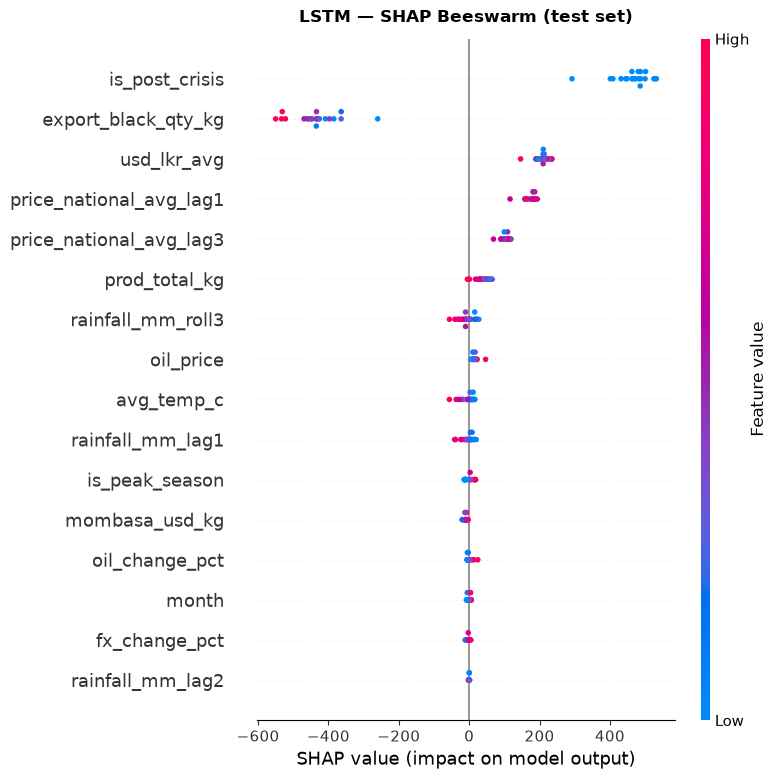

Saved: 16_lstm_shap_beeswarm.png


In [9]:
shap_exp_lstm = shap.Explanation(
    values=shap_lstm,
    data=X_lstm_display,
    feature_names=LSTM_FEATURES,
)
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_exp_lstm, max_display=len(LSTM_FEATURES), show=False)
plt.title('LSTM — SHAP Beeswarm (test set)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/16_lstm_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_lstm_shap_beeswarm.png')


## 2. XGBoost (core) — TreeSHAP

TreeSHAP is exact (not approximate). The core 17-feature set gives cleaner
attributions than the full feature set.


In [10]:
xgb_core = xgb.XGBRegressor()
xgb_core.load_model(f'{MODEL_DIR}/xgb_core_model.json')

with open(f'{MODEL_DIR}/core_features.json') as f:
    CORE_FEATURES = [c for c in json.load(f) if c in test_df.columns]

X_train_core = train_df[CORE_FEATURES].values
X_test_core  = test_df[CORE_FEATURES].values

print(f'Core features ({len(CORE_FEATURES)}): {CORE_FEATURES}')


Core features (17): ['price_national_avg_lag1', 'price_national_avg_lag3', 'rainfall_mm', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'avg_temp_c', 'usd_lkr_avg', 'fx_change_pct', 'oil_price', 'mombasa_usd_kg', 'export_black_qty_kg', 'export_black_fob_avg', 'prod_total_kg', 'month', 'is_peak_season', 'is_post_crisis', 'sentiment_score']


In [11]:
explainer_xgb = shap.TreeExplainer(xgb_core)
shap_xgb      = explainer_xgb.shap_values(X_test_core)  # (n_test, n_features)
print(f'XGBoost SHAP shape: {np.array(shap_xgb).shape}')


XGBoost SHAP shape: (21, 17)


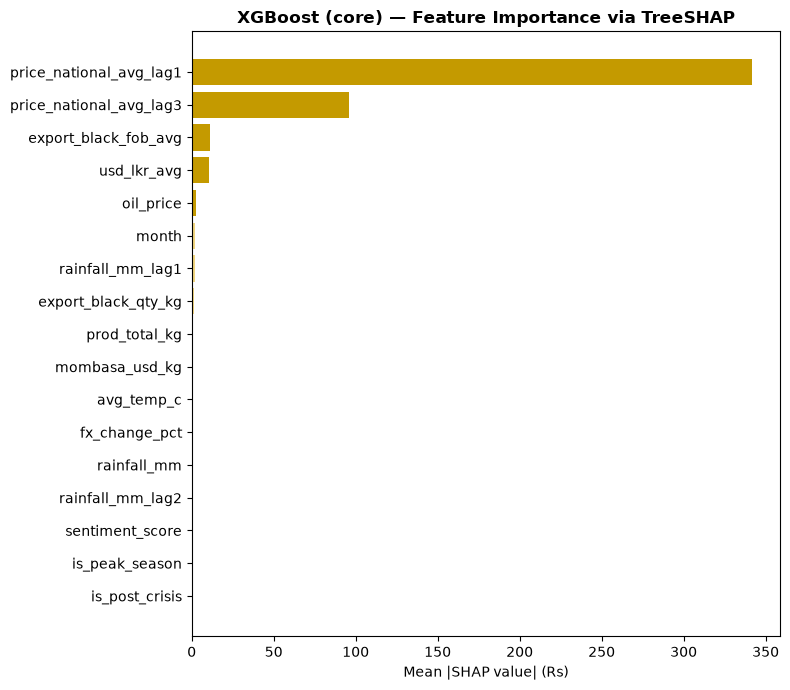

Saved: 17_xgb_shap_bar.png

Top 5 XGBoost (core) features:
                feature  importance
              oil_price    2.402003
            usd_lkr_avg   10.492185
   export_black_fob_avg   11.151274
price_national_avg_lag3   95.763344
price_national_avg_lag1  341.664886


In [12]:
mean_abs_xgb = np.abs(shap_xgb).mean(axis=0)
xgb_imp_df   = pd.DataFrame({'feature': CORE_FEATURES, 'importance': mean_abs_xgb})\
                 .sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
threshold_xgb = xgb_imp_df['importance'].quantile(0.75)
colors_xgb = ['#C49A00' if v >= threshold_xgb else '#F0D580'
               for v in xgb_imp_df['importance']]
ax.barh(xgb_imp_df['feature'], xgb_imp_df['importance'], color=colors_xgb)
ax.set_xlabel('Mean |SHAP value| (Rs)')
ax.set_title('XGBoost (core) — Feature Importance via TreeSHAP', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/17_xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 17_xgb_shap_bar.png')
print('\nTop 5 XGBoost (core) features:')
print(xgb_imp_df.tail(5)[['feature','importance']].to_string(index=False))


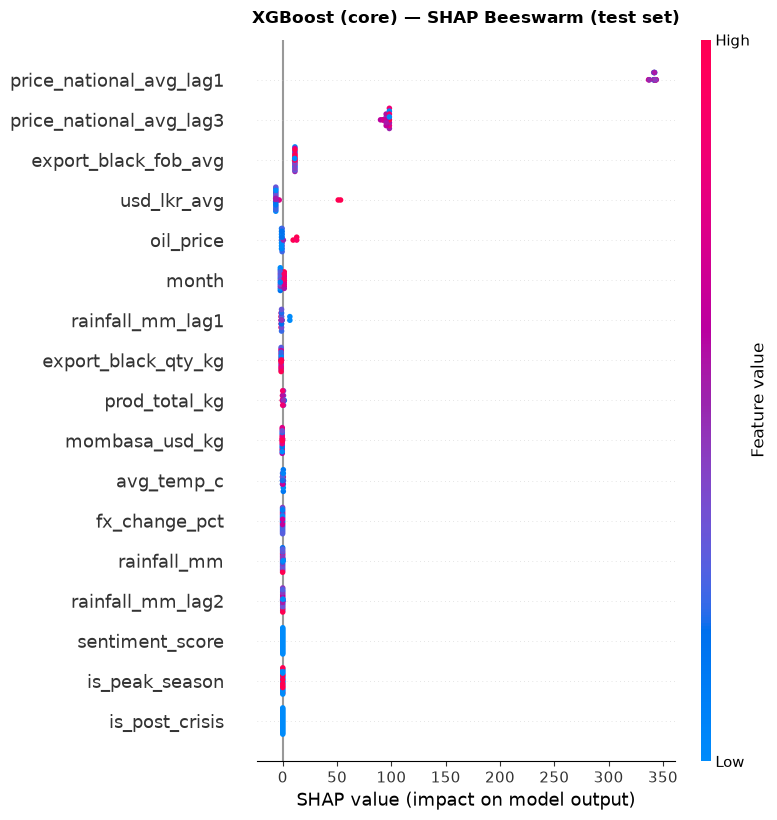

Saved: 18_xgb_shap_beeswarm.png


In [13]:
shap_exp_xgb = shap.Explanation(
    values=np.array(shap_xgb),
    data=X_test_core,
    feature_names=CORE_FEATURES,
)
plt.figure(figsize=(9, 7))
shap.plots.beeswarm(shap_exp_xgb, max_display=len(CORE_FEATURES), show=False)
plt.title('XGBoost (core) — SHAP Beeswarm (test set)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/18_xgb_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 18_xgb_shap_beeswarm.png')


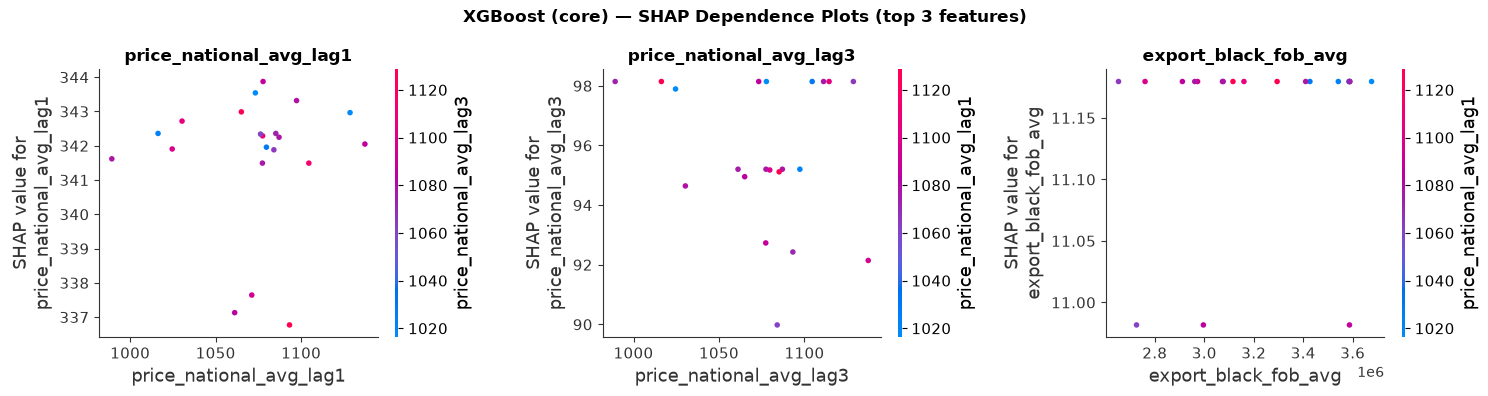

Saved: 19_xgb_shap_dependence.png


In [14]:
top3 = xgb_imp_df['feature'].tail(3).tolist()[::-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top3):
    feat_idx = CORE_FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx, np.array(shap_xgb), X_test_core,
        feature_names=CORE_FEATURES, ax=ax, show=False,
    )
    ax.set_title(feat, fontweight='bold')
fig.suptitle('XGBoost (core) — SHAP Dependence Plots (top 3 features)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_DIR}/19_xgb_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 19_xgb_shap_dependence.png')


## 3. Summary

Fill in after running:

- **LSTM top features**: *(from 15_lstm_shap_bar.png)*
- **XGBoost top features**: *(from 17_xgb_shap_bar.png)*
- **Common drivers**: Features appearing in both models are the most robust findings.
- **Dependence plots**: show how each top feature's value shifts the predicted price.
